In [ ]:
!pip install -U diffusers transformers accelerate torch torchvision -q
!pip uninstall -y torchaudio -q

In [2]:
from kaggle_secrets import UserSecretsClient
from huggingface_hub import login

user_secrets = UserSecretsClient()
HF_TOKEN = user_secrets.get_secret("HF_TOKEN")
login(token=HF_TOKEN)
print("تم تسجيل الدخول ✅")

تم تسجيل الدخول ✅


In [3]:
import requests
url = "https://raw.githubusercontent.com/maram-elaian/brandora/main/data/test_briefs.json"
briefs = requests.get(url).json()
print(f"عدد البريفات: {len(briefs)}")

عدد البريفات: 30


In [ ]:
!pip install -U bitsandbytes -q

In [4]:
import os
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

import torch, gc
from diffusers import FluxPipeline, FluxTransformer2DModel, BitsAndBytesConfig as DiffusersBnBConfig
from transformers import T5EncoderModel, BitsAndBytesConfig as TransformersBnBConfig

model_id = "black-forest-labs/FLUX.1-schnell"

# --- T5 أولاً، على GPU فاضية بالكامل ---
text_encoder_quant_config = TransformersBnBConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16,
)
text_encoder_2 = T5EncoderModel.from_pretrained(
    model_id, subfolder="text_encoder_2",
    quantization_config=text_encoder_quant_config,
    torch_dtype=torch.bfloat16,
)
print(f"بعد الـ T5: {torch.cuda.memory_allocated()/1e9:.2f} GB")

# --- الترانسفورمر ثانياً ---
transformer_quant_config = DiffusersBnBConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16,
)
transformer = FluxTransformer2DModel.from_pretrained(
    model_id, subfolder="transformer",
    quantization_config=transformer_quant_config,
    torch_dtype=torch.bfloat16,
)
print(f"بعد الـ transformer: {torch.cuda.memory_allocated()/1e9:.2f} GB")

pipe = FluxPipeline.from_pretrained(
    model_id,
    transformer=transformer,
    text_encoder_2=text_encoder_2,
    torch_dtype=torch.bfloat16,
)
pipe.enable_model_cpu_offload()

print("✅ الموديل جاهز")

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/219 [00:00<?, ?it/s]

بعد الـ T5: 6.33 GB


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


...

model_index.json:   0%|          | 0.00/536 [00:00<?, ?B/s]

Fetching 14 files:   0%|          | 0/14 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

✅ الموديل جاهز


In [5]:
def brief_to_image_prompt(b):
    return (
        f"{b['logo_direction']}, professional corporate branding, "
        f"flat vector design, Adobe Illustrator style, geometric, "
        f"minimalist icon, clean background, no text, no cartoon, no mascot"
    )
test_briefs = briefs[:30]

for brief in test_briefs:
    prompt = brief_to_image_prompt(brief)
    image = pipe(prompt, num_inference_steps=4, guidance_scale=0.0).images[0]
    filename = f"FLUX_{brief['id']}.png"
    image.save(filename)
    print(f"✅ {brief['id']} → {filename}")

  0%|          | 0/4 [00:00<?, ?it/s]

✅ BR001 → FLUX_BR001.png


  0%|          | 0/4 [00:00<?, ?it/s]

✅ BR002 → FLUX_BR002.png


  0%|          | 0/4 [00:00<?, ?it/s]

...

✅ BR028 → FLUX_BR028.png


  0%|          | 0/4 [00:00<?, ?it/s]

✅ BR029 → FLUX_BR029.png


  0%|          | 0/4 [00:00<?, ?it/s]

✅ BR030 → FLUX_BR030.png


📊 جاري تجهيز العرض لـ 30 صور...
   الشبكة: 6 صفوف × 5 أعمدة


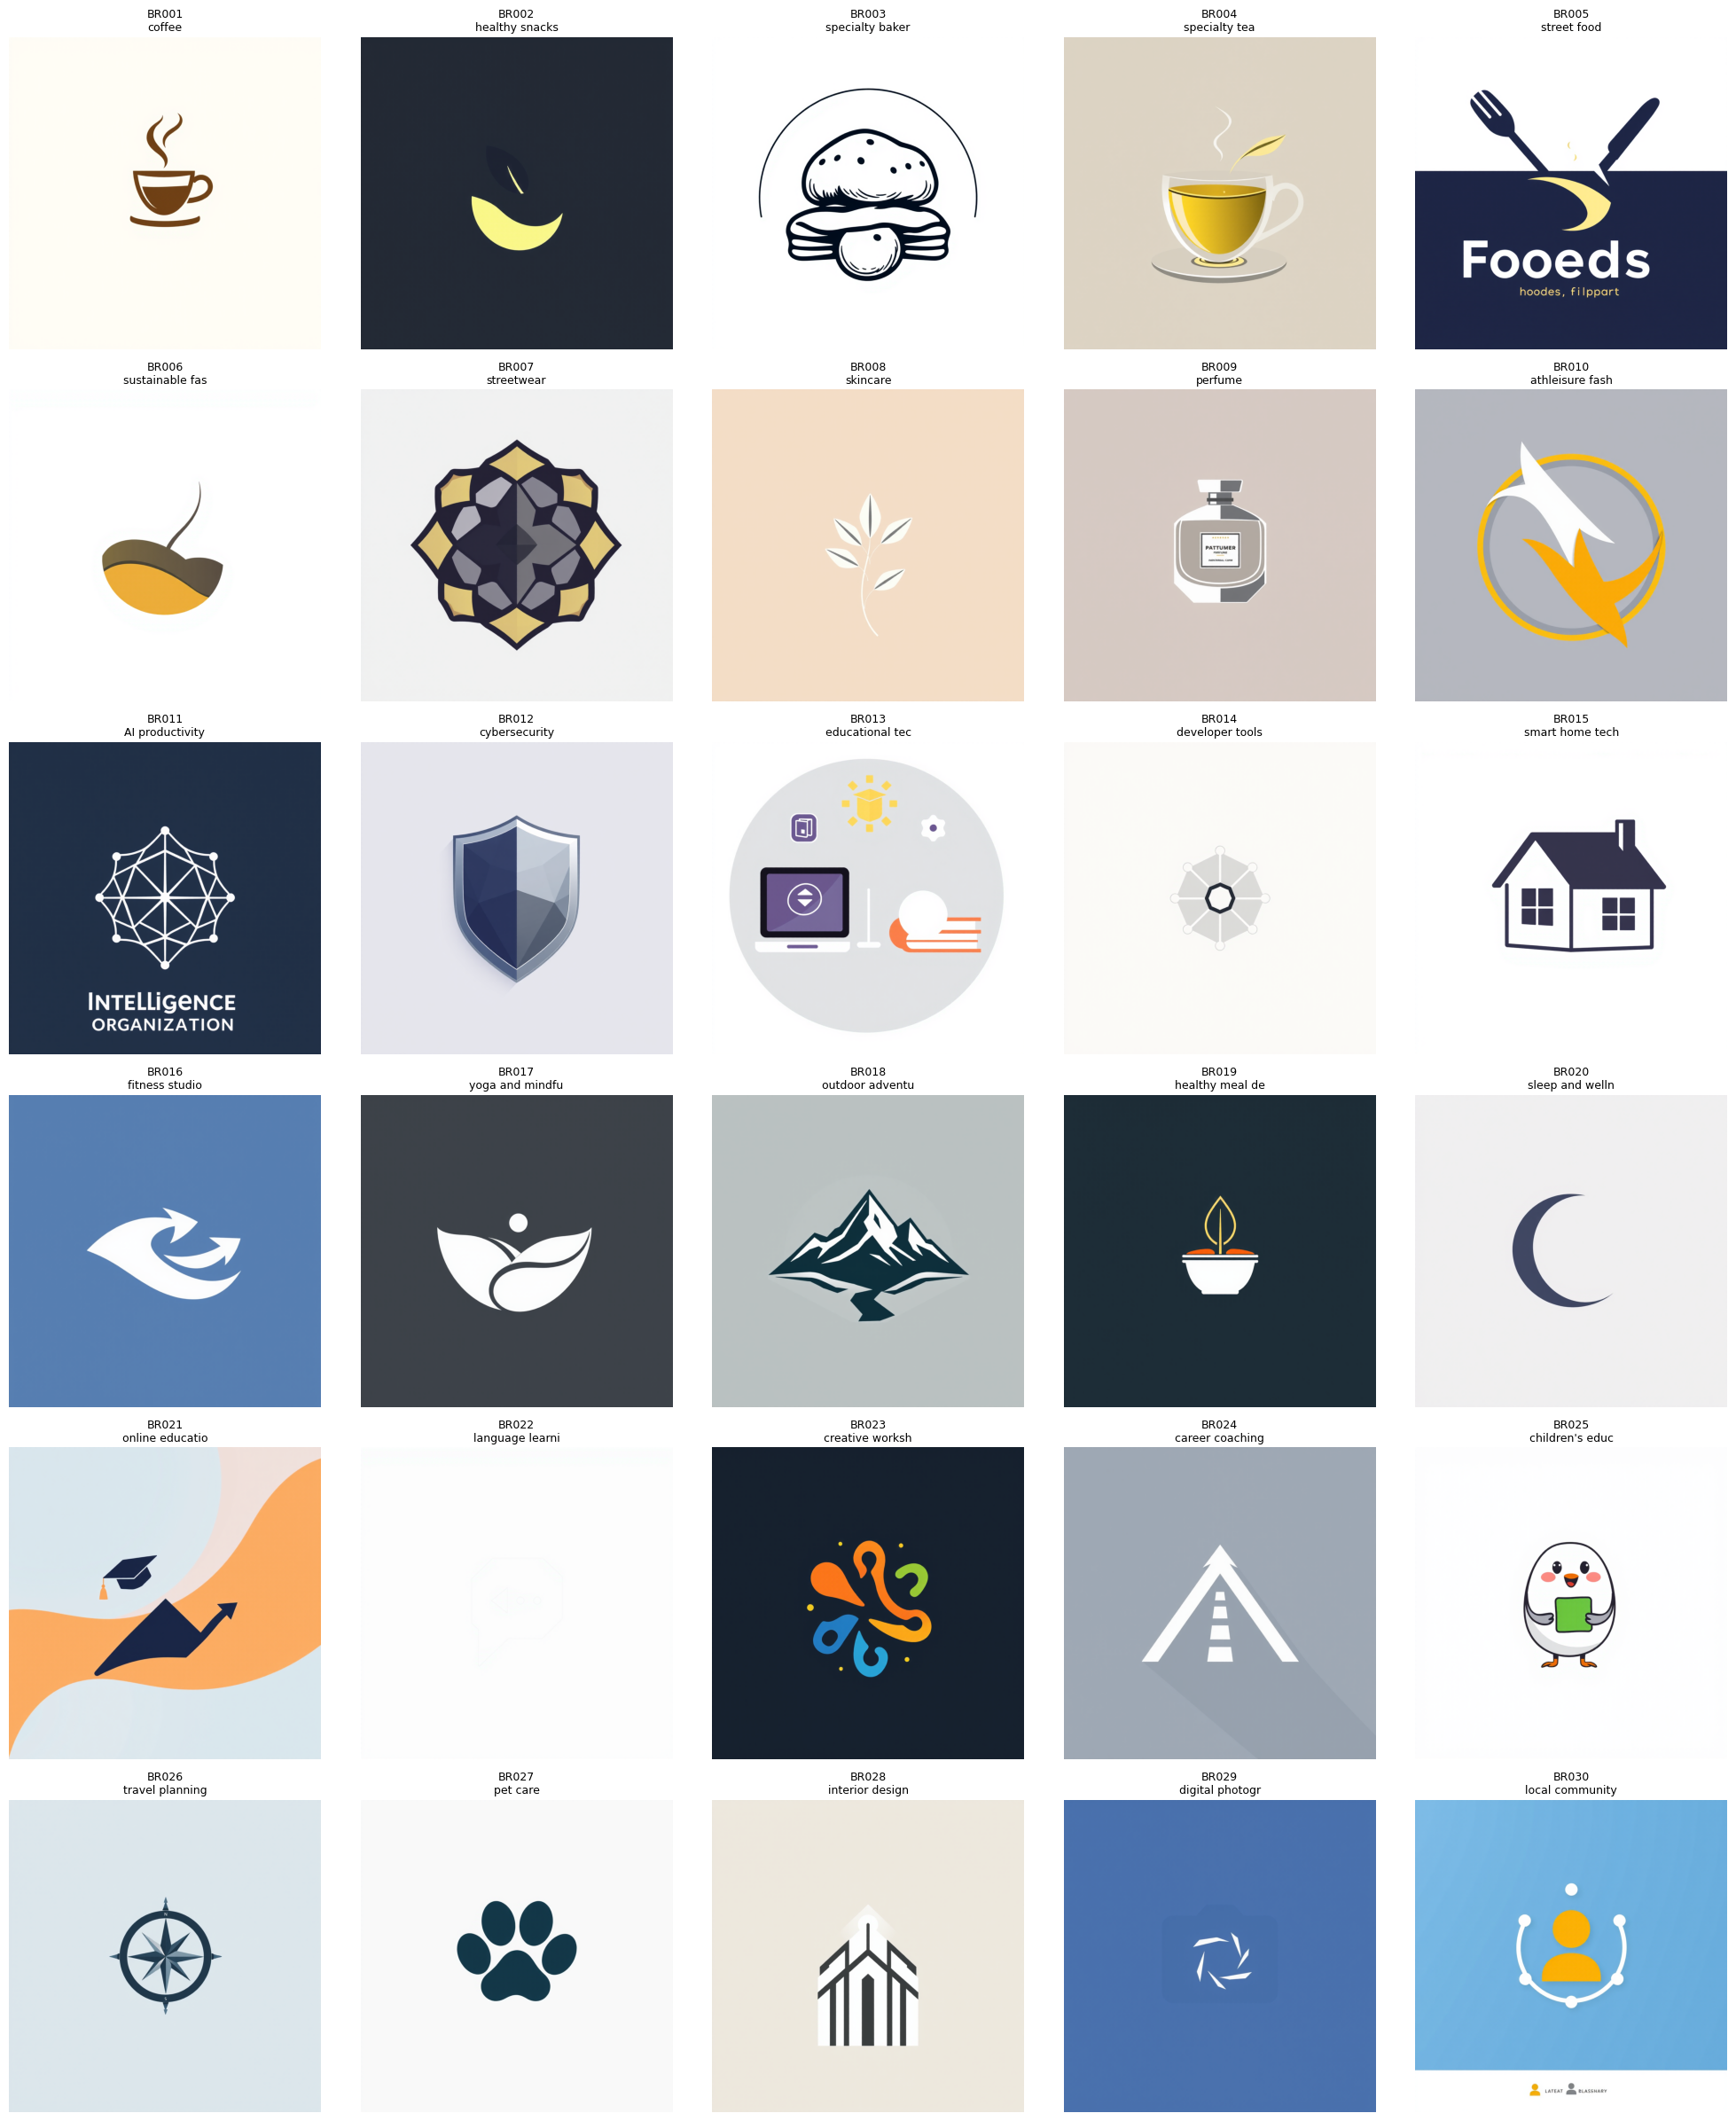

✅ تم عرض 30 صور بنجاح.
📸 تم حفظ الملف: flux_all_30_results_grid.png


In [12]:
import matplotlib.pyplot as plt
from PIL import Image
import os

# تحديد عدد البريفات المراد عرضها
NUM_TO_SHOW = 30

# تحميل قائمة البريفات للتأكد من الترتيب والعناوين
url = "https://raw.githubusercontent.com/maram-elaian/brandora/main/data/test_briefs.json"
briefs = requests.get(url).json()[:NUM_TO_SHOW]

# حساب أبعاد الشبكة (Rows x Columns)
cols = 5
rows = (len(briefs) + cols - 1) // cols  # قسمة سقفية لحساب الصفوف المطلوبة

print(f"📊 جاري تجهيز العرض لـ {len(briefs)} صور...")
print(f"   الشبكة: {rows} صفوف × {cols} أعمدة")

fig, axes = plt.subplots(rows, cols, figsize=(20, 4 * rows))

# تحويل axes إلى مسطحة لتسهيل المرور عليها
if rows == 1:
    axes = [axes]
else:
    axes = axes.flatten()

generated_count = 0

for i, brief in enumerate(briefs):
    filename = f"FLUX_{brief['id']}.png"
    
    if os.path.exists(filename):
        try:
            img = Image.open(filename)
            ax = axes[i]
            ax.imshow(img)
            # العنوان: ID + الصناعة المختصرة
            title = f"{brief['id']}\n{brief['industry'][:15]}" 
            ax.set_title(title, fontsize=9, pad=5)
            ax.axis('off')
            generated_count += 1
        except Exception as e:
            print(f"⚠️ خطأ في فتح {filename}: {e}")
            axes[i].axis('off')
    else:
        # إذا لم تكن الصورة موجودة بعد
        axes[i].text(0.5, 0.5, "Not Generated", ha='center', va='center', color='red')
        axes[i].set_title(f"{brief['id']}", fontsize=9)
        axes[i].axis('off')

# إخفاء الخلايا الفارغة المتبقية في الشبكة (إذا كان العدد ليس مضاعفاً للـ cols)
for j in range(len(briefs), len(axes)):
    axes[j].axis('off')

plt.tight_layout(pad=1.0)
plt.savefig("flux_all_30_results_grid.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"✅ تم عرض {generated_count} صور بنجاح.")
print("📸 تم حفظ الملف: flux_all_30_results_grid.png")